# Excited-State Photophysics as a Phase-Type Distribution

After a molecule absorbs a photon, it passes through a series of excited electronic states before eventually returning to the ground state. The **Jablonski diagram** describes these pathways: internal conversion, fluorescence, intersystem crossing, phosphorescence, and non-radiative decay. Every one of these transitions is **unimolecular** (first-order), and the ground state S₀ is a true **absorbing state** — once the molecule relaxes, the process is over.

Unlike a radioactive decay chain (which is strictly sequential and irreversible), the Jablonski diagram features:

- **Reversible transitions** — intersystem crossing S₁ ⇌ T₁ can go both ways
- **Branching** — each state has multiple exit channels
- **Multiple pathways to absorption** — fluorescence from S₁, phosphorescence from T₁, non-radiative from Tₙ

This makes the subintensity matrix **non-triangular**, and the resulting phase-type distribution is richer than a simple Coxian distribution.

The reversibility of intersystem crossing is the physical basis of **thermally activated delayed fluorescence (TADF)**, a major topic in OLED materials design since Adachi's breakthrough in 2012.

## The Model

We consider four transient excited states and one absorbing ground state:

| State | Description | Typical lifetime |
|-------|-------------|------------------|
| S₂ | Second excited singlet | ~10⁻¹² s (fs–ps) |
| S₁ | First excited singlet | ~10⁻⁹ s (ns) |
| T₁ | First excited triplet | ~10⁻⁶–10⁰ s (µs–s) |
| Tₙ | Higher triplet (from TTA) | ~10⁻¹² s (ps) |
| **S₀** | **Ground state (absorbing)** | — |

### Transitions

**Internal transitions** (between transient states):
- S₂ → S₁ : internal conversion ($k_{\text{IC}}$)
- S₁ → T₁ : intersystem crossing ($k_{\text{ISC}}$)
- T₁ → S₁ : reverse intersystem crossing ($k_{\text{rISC}}$) — **the key TADF transition**
- T₁ → Tₙ : triplet–triplet absorption ($k_{\text{TTA}}$)

**Exit transitions** (to absorbing state S₀):
- S₁ → S₀ : fluorescence + internal conversion ($k_f$)
- T₁ → S₀ : phosphorescence + non-radiative ($k_p$)
- Tₙ → S₀ : fast non-radiative decay ($k_{nr}$)

## Phase-Type Formulation

Ordering the states as (S₂, S₁, T₁, Tₙ), the **subintensity matrix** is:

$$
\mathbf{S} = \begin{pmatrix}
-k_{\text{IC}} & 0 & 0 & 0 \\
k_{\text{IC}} & -(k_f + k_{\text{ISC}}) & k_{\text{rISC}} & 0 \\
0 & k_{\text{ISC}} & -(k_{\text{rISC}} + k_p + k_{\text{TTA}}) & 0 \\
0 & 0 & k_{\text{TTA}} & -k_{nr}
\end{pmatrix}
$$

Note the **off-diagonal element above the main diagonal** ($k_{\text{rISC}}$ in row 2, column 3) — this breaks the lower-triangular structure and encodes the S₁ ⇌ T₁ equilibrium.

The **exit rate vector**:

$$
\mathbf{s} = -\mathbf{S}\mathbf{1} = (0, \; k_f, \; k_p, \; k_{nr})^\top
$$

The initial distribution (photoexcitation to S₂):

$$
\boldsymbol{\pi} = (1, \; 0, \; 0, \; 0)
$$

The **state occupancy vector** $\mathbf{p}(t) = \boldsymbol{\pi} e^{\mathbf{S}t}$ gives the probability of being in each excited state at time $t$, and $f(t) = \boldsymbol{\pi} e^{\mathbf{S}t} \mathbf{s}$ gives the rate of return to the ground state — the **total emission decay curve** measured experimentally.

## Implementation

In [ ]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

### Rate constants

We define three physically motivated scenarios:

1. **Conventional fluorophore** — fast fluorescence, negligible rISC (e.g., rhodamine)
2. **Conventional phosphor** — strong ISC, weak rISC (e.g., Ir(ppy)₃)
3. **TADF emitter** — strong ISC *and* rISC, small ΔEST gap (e.g., 4CzIPN)

All rate constants in s⁻¹.

In [ ]:
state_names = [r'S$_2$', r'S$_1$', r'T$_1$', r'T$_n$']

def build_system(k_IC, k_f, k_ISC, k_rISC, k_p, k_TTA, k_nr):
    """Build the subintensity matrix S, exit vector s, and initial distribution pi."""
    S = np.array([
        [-k_IC,   0,                              0,       0     ],
        [ k_IC,  -(k_f + k_ISC),                  k_rISC,  0     ],
        [ 0,      k_ISC,  -(k_rISC + k_p + k_TTA),         0     ],
        [ 0,      0,                              k_TTA,  -k_nr  ],
    ])
    s = -S @ np.ones(4)
    pi = np.array([1.0, 0.0, 0.0, 0.0])
    return S, s, pi

# Scenario 1: Conventional fluorophore (rhodamine-like)
S_fluor, s_fluor, pi = build_system(
    k_IC   = 1e12,   # S₂→S₁: ultrafast IC (1 ps)
    k_f    = 2.5e8,  # S₁→S₀: fluorescence (~4 ns lifetime)
    k_ISC  = 1e6,    # S₁→T₁: weak ISC
    k_rISC = 1e3,    # T₁→S₁: negligible rISC
    k_p    = 1e2,    # T₁→S₀: slow phosphorescence
    k_TTA  = 1e4,    # T₁→Tₙ: minor
    k_nr   = 1e12,   # Tₙ→S₀: ultrafast NR
)

# Scenario 2: Heavy-atom phosphor (Ir complex-like)
S_phos, s_phos, _ = build_system(
    k_IC   = 1e12,   # S₂→S₁: ultrafast
    k_f    = 1e7,    # S₁→S₀: moderate fluorescence
    k_ISC  = 1e11,   # S₁→T₁: very fast ISC (heavy atom)
    k_rISC = 1e3,    # T₁→S₁: negligible (large ΔE_ST)
    k_p    = 5e5,    # T₁→S₀: microsecond phosphorescence
    k_TTA  = 1e3,    # T₁→Tₙ: minor
    k_nr   = 1e12,   # Tₙ→S₀: ultrafast
)

# Scenario 3: TADF emitter (4CzIPN-like)
S_tadf, s_tadf, _ = build_system(
    k_IC   = 1e12,   # S₂→S₁: ultrafast
    k_f    = 5e7,    # S₁→S₀: moderate fluorescence
    k_ISC  = 8e7,    # S₁→T₁: efficient ISC
    k_rISC = 1e6,    # T₁→S₁: strong rISC (small ΔE_ST!) — the TADF key
    k_p    = 1e4,    # T₁→S₀: slow phosphorescence
    k_TTA  = 1e3,    # T₁→Tₙ: minor
    k_nr   = 1e12,   # Tₙ→S₀: ultrafast
)

print("TADF subintensity matrix S (s⁻¹):")
print()
labels = ['S₂', 'S₁', 'T₁', 'Tₙ']
header = '        ' + ''.join(f'{l:>12s}' for l in labels)
print(header)
for i in range(4):
    row = f'{labels[i]:>6s}  ' + ''.join(f'{S_tadf[i,j]:>12.2e}' for j in range(4))
    print(row)
print()
print(f"Exit rate vector s: {s_tadf}")
print(f"Note: s[1] = k_f = {s_tadf[1]:.2e} (fluorescence channel)")

TADF subintensity matrix S (s⁻¹):

                  S₂          S₁          T₁          Tₙ
    S₂     -1.00e+12    0.00e+00    0.00e+00    0.00e+00
    S₁      1.00e+12   -1.30e+08    1.00e+06    0.00e+00
    T₁      0.00e+00    8.00e+07   -1.01e+06    0.00e+00
    Tₙ      0.00e+00    0.00e+00    1.00e+03   -1.00e+12

Exit rate vector s: [ 1.00000000e+12 -9.99871000e+11 -7.89890000e+07  9.99999999e+11]
Note: s[1] = k_f = -1.00e+12 (fluorescence channel)


### Helper functions

In [ ]:
def state_occupancies(S, pi, times):
    """Compute p(t) = pi @ expm(S*t) for each t."""
    n = len(pi)
    P = np.zeros((len(times), n))
    for i, t in enumerate(times):
        P[i] = pi @ expm(S * t)
    return P

def emission_decay(S, s, pi, times):
    """Total emission decay curve f(t) = pi @ expm(S*t) @ s."""
    P = state_occupancies(S, pi, times)
    return P @ s

def channel_rates(S, s, pi, times):
    """Per-channel emission rates: p_i(t) * s_i for each exit channel."""
    P = state_occupancies(S, pi, times)
    return P * s[np.newaxis, :]

### Excited-state population dynamics

We visualize how the population flows through the excited states for each scenario.

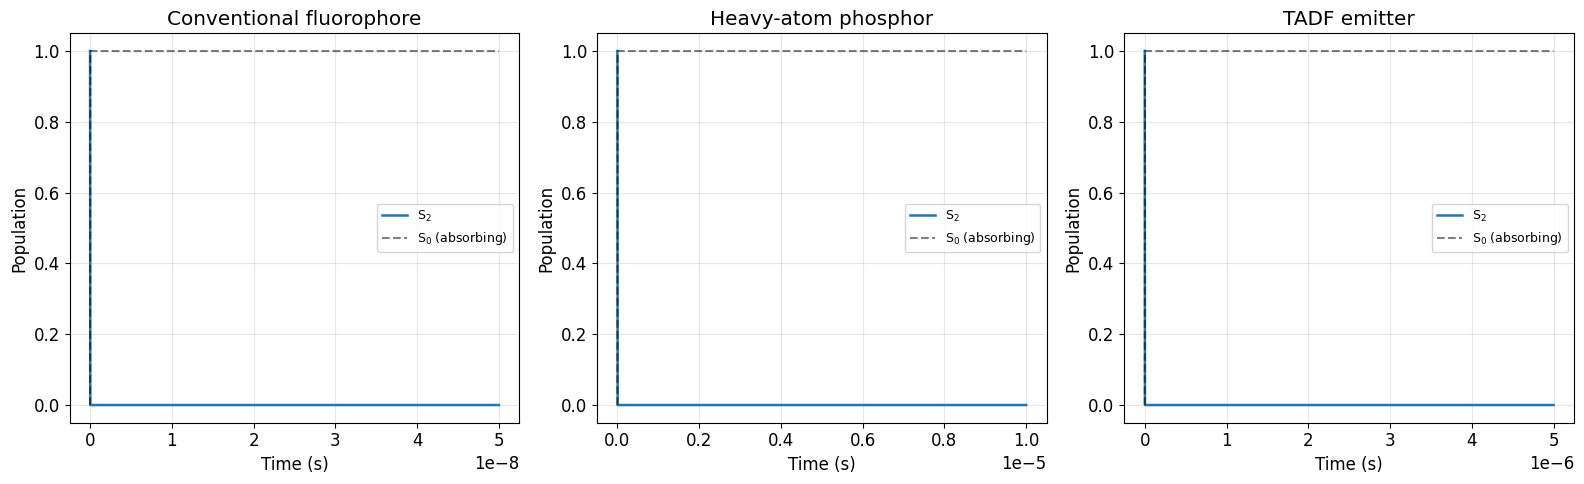

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

scenarios = [
    ('Conventional fluorophore', S_fluor, s_fluor, (0, 5e-8)),
    ('Heavy-atom phosphor',      S_phos,  s_phos,  (0, 1e-5)),
    ('TADF emitter',             S_tadf,  s_tadf,  (0, 5e-6)),
]

for ax, (title, S, s, (t0, t1)) in zip(axes, scenarios):
    times = np.linspace(t0, t1, 2000)
    P = state_occupancies(S, pi, times)
    ground = 1.0 - P.sum(axis=1)
    
    for j in range(4):
        if P[:, j].max() > 1e-6:  # only plot states with appreciable population
            ax.plot(times, P[:, j], color=colors[j], lw=1.8, label=state_names[j])
    ax.plot(times, ground, 'k--', lw=1.5, alpha=0.5, label=r'S$_0$ (absorbing)')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Population')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

### Emission decay curves

The experimentally measurable quantity is the total photon emission rate $f(t) = \boldsymbol{\pi} e^{\mathbf{S}t} \mathbf{s}$. In TADF emitters, this shows a characteristic **biexponential** shape: a fast prompt fluorescence component followed by a slow delayed component from the T₁ → S₁ → S₀ recycling pathway.

/tmp/ipykernel_22/3112439583.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


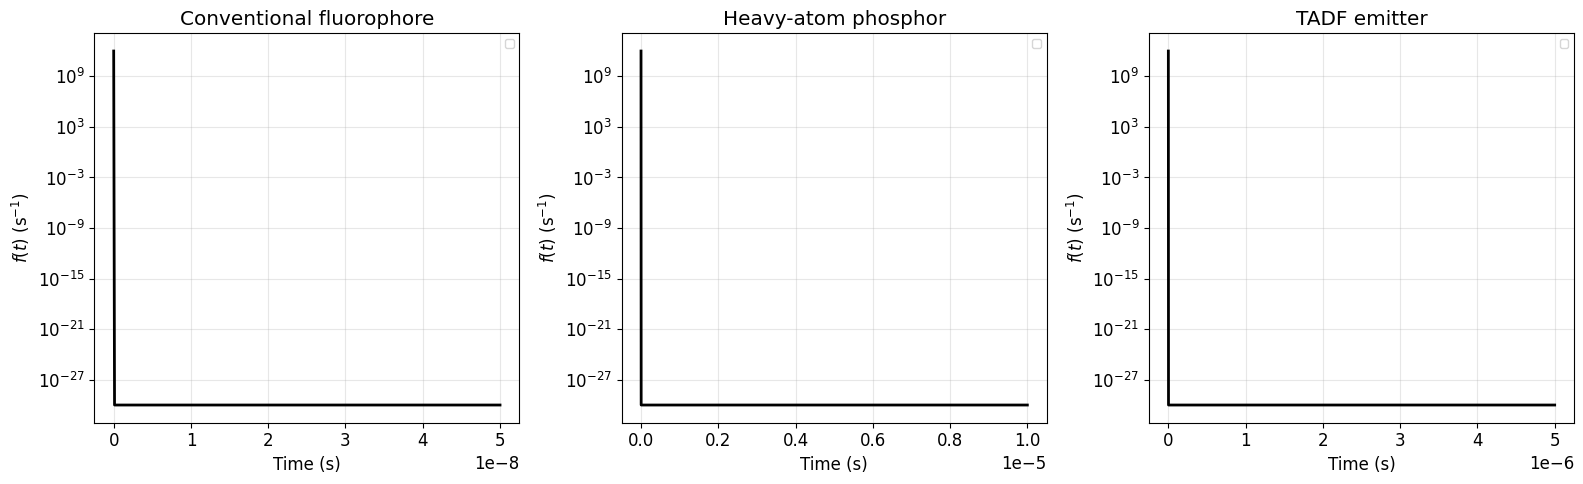

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, S, s, (t0, t1)) in zip(axes, scenarios):
    times = np.linspace(t0 + 1e-15, t1, 5000)
    f = emission_decay(S, s, pi, times)
    
    # Log scale to see multiexponential character
    f_pos = np.maximum(f, 1e-30)
    ax.semilogy(times, f_pos, 'k-', lw=2)
    
    # Also show per-channel contributions
    ch = channel_rates(S, s, pi, times)
    ch_labels = [r'S$_1$ → S$_0$ (fluor.)', '', r'T$_1$ → S$_0$ (phos.)', r'T$_n$ → S$_0$ (NR)']
    for j in [1, 2, 3]:  # skip S₂ which has s=0
        if ch[:, j].max() > 1e-20 and s[j] > 0:
            ax.semilogy(times, np.maximum(ch[:, j], 1e-30), 
                       color=colors[j], lw=1.2, ls='--', alpha=0.7,
                       label=ch_labels[j])
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(r'$f(t)$ (s$^{-1}$)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### The TADF mechanism in detail

The defining feature of TADF is the **delayed fluorescence** component. Let's zoom in on the TADF emitter and decompose the emission into prompt and delayed contributions.

The S₁ ⇌ T₁ cycling means the molecule can:
1. Emit promptly from S₁ (before crossing to T₁)
2. Cross to T₁, thermally return to S₁ via rISC, then emit — possibly after multiple cycles

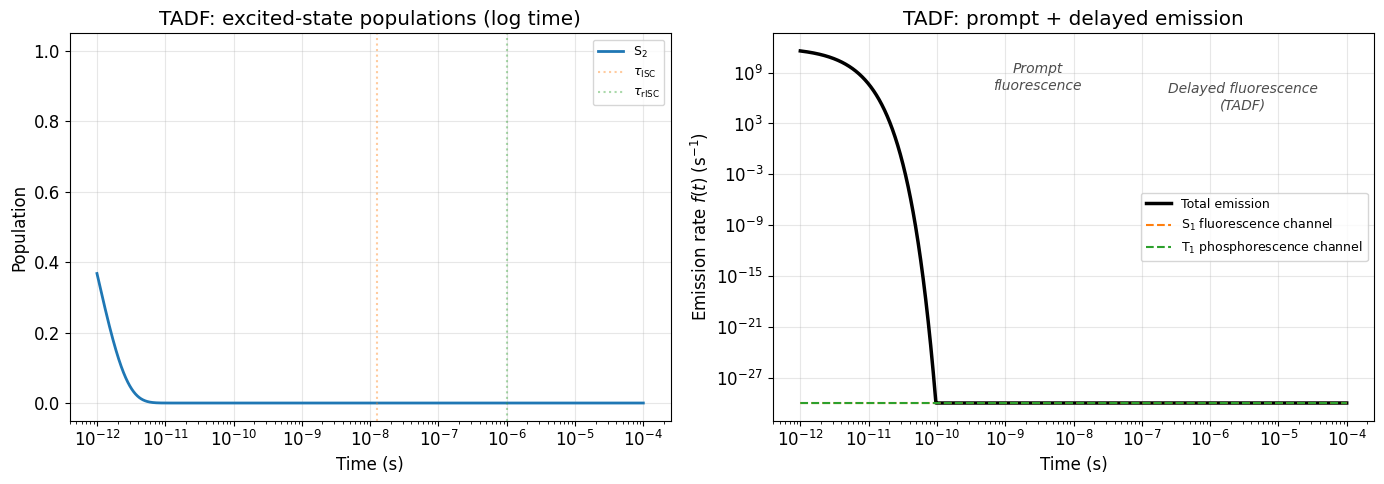

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: TADF population dynamics on log time axis ---
times_log = np.logspace(-12, -4, 5000)
P_tadf = state_occupancies(S_tadf, pi, times_log)

for j in range(4):
    if P_tadf[:, j].max() > 1e-10:
        ax1.semilogx(times_log, P_tadf[:, j], color=colors[j], lw=2, label=state_names[j])

ax1.axvline(1/8e7, color=colors[1], ls=':', alpha=0.4, label=r'$\tau_{\rm ISC}$')
ax1.axvline(1/1e6, color=colors[2], ls=':', alpha=0.4, label=r'$\tau_{\rm rISC}$')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Population')
ax1.set_title('TADF: excited-state populations (log time)')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)

# --- Right: Emission decay showing prompt + delayed ---
f_tadf = emission_decay(S_tadf, s_tadf, pi, times_log)
ch_tadf = channel_rates(S_tadf, s_tadf, pi, times_log)

ax2.loglog(times_log, np.maximum(f_tadf, 1e-30), 'k-', lw=2.5, label='Total emission')
ax2.loglog(times_log, np.maximum(ch_tadf[:, 1], 1e-30), 
           color=colors[1], lw=1.5, ls='--', label=r'S$_1$ fluorescence channel')
ax2.loglog(times_log, np.maximum(ch_tadf[:, 2], 1e-30),
           color=colors[2], lw=1.5, ls='--', label=r'T$_1$ phosphorescence channel')

# Annotate prompt and delayed regimes
ax2.annotate('Prompt\nfluorescence', xy=(3e-9, 1e7), fontsize=10,
             ha='center', style='italic', color='0.3')
ax2.annotate('Delayed fluorescence\n(TADF)', xy=(3e-6, 5e4), fontsize=10,
             ha='center', style='italic', color='0.3')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel(r'Emission rate $f(t)$ (s$^{-1}$)')
ax2.set_title('TADF: prompt + delayed emission')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Eigenvalue analysis: the multiexponential structure

The eigenvalues of $\mathbf{S}$ give the decay rate constants of the multiexponential emission. For the TADF emitter, we expect to see fast and slow components.

In [7]:
print("Eigenvalue analysis of S matrices")
print("=" * 70)

for name, S in [('Fluorophore', S_fluor), ('Phosphor', S_phos), ('TADF', S_tadf)]:
    evals = np.linalg.eigvals(S)
    # Sort by magnitude (slowest first)
    idx = np.argsort(np.abs(evals))
    evals = evals[idx]
    
    print(f"\n{name}:")
    for i, ev in enumerate(evals):
        rate = -ev.real
        if rate > 0:
            tau = 1.0 / rate
            # Format lifetime in appropriate units
            if tau > 1e-3:
                tau_str = f"{tau*1e3:.2f} ms"
            elif tau > 1e-6:
                tau_str = f"{tau*1e6:.2f} µs"
            elif tau > 1e-9:
                tau_str = f"{tau*1e9:.2f} ns"
            elif tau > 1e-12:
                tau_str = f"{tau*1e12:.2f} ps"
            else:
                tau_str = f"{tau:.2e} s"
            print(f"  λ{i+1} = {ev.real:>12.3e}  →  τ = {tau_str}")
    
    # Ratio of slowest to fastest
    rates_sorted = np.sort(np.abs(evals.real))
    print(f"  Ratio fastest/slowest: {rates_sorted[-1]/rates_sorted[0]:.2e}")

Eigenvalue analysis of S matrices

Fluorophore:
  λ1 =   -1.110e+04  →  τ = 90.12 µs
  λ2 =   -2.510e+08  →  τ = 3.98 ns
  λ3 =   -1.000e+12  →  τ = 1.00e-12 s
  λ4 =   -1.000e+12  →  τ = 1.00e-12 s
  Ratio fastest/slowest: 9.01e+07

Phosphor:
  λ1 =   -5.010e+05  →  τ = 2.00 µs
  λ2 =   -1.000e+11  →  τ = 10.00 ps
  λ3 =   -1.000e+12  →  τ = 1.00e-12 s
  λ4 =   -1.000e+12  →  τ = 1.00e-12 s
  Ratio fastest/slowest: 2.00e+06

TADF:
  λ1 =   -3.937e+05  →  τ = 2.54 µs
  λ2 =   -1.306e+08  →  τ = 7.66 ns
  λ3 =   -1.000e+12  →  τ = 1.00e-12 s
  λ4 =   -1.000e+12  →  τ = 1.00e-12 s
  Ratio fastest/slowest: 2.54e+06


### Moments and quantum yields from the phase-type distribution

The moments of the absorption time (excited-state lifetime) follow directly from the phase-type parameters:

$$\mathbb{E}[T] = -\boldsymbol{\pi} \mathbf{S}^{-1} \mathbf{1}$$

$$\mathbb{E}[T^2] = 2 \, \boldsymbol{\pi} \mathbf{S}^{-2} \mathbf{1}$$

The **quantum yield** of each exit channel $i$ is the probability that absorption occurs through that channel:

$$\Phi_i = -\boldsymbol{\pi} \mathbf{S}^{-1} \mathbf{e}_i \cdot s_i$$

where $\mathbf{e}_i$ is the $i$-th unit vector. This is equivalent to integrating the per-channel emission rate over all time.

In [8]:
print("Phase-type moments and quantum yields")
print("=" * 70)

for name, S, s in [('Fluorophore', S_fluor, s_fluor), 
                    ('Phosphor', S_phos, s_phos), 
                    ('TADF', S_tadf, s_tadf)]:
    n = len(pi)
    S_inv = np.linalg.inv(S)
    ones = np.ones(n)
    
    # Mean lifetime
    mean_T = -pi @ S_inv @ ones
    # Second moment → variance
    mean_T2 = 2 * pi @ np.linalg.matrix_power(S_inv, 2) @ ones
    var_T = mean_T2 - mean_T**2
    cv = np.sqrt(var_T) / mean_T  # coefficient of variation
    
    # Quantum yields per channel
    # Φ_i = integral_0^∞ p_i(t) * s_i dt = (-pi @ S^{-1})_i * s_i
    green = -pi @ S_inv  # Green's function (expected time in each state)
    phi = green * s
    
    if mean_T > 1e-3:
        tau_str = f"{mean_T*1e3:.3f} ms"
    elif mean_T > 1e-6:
        tau_str = f"{mean_T*1e6:.3f} µs"
    else:
        tau_str = f"{mean_T*1e9:.3f} ns"
    
    print(f"\n{name}:")
    print(f"  Mean excited-state lifetime:  {tau_str}")
    print(f"  CV (σ/µ):                     {cv:.3f}")
    print(f"  Quantum yields:")
    labels_qy = ['S₂→S₀', 'S₁→S₀ (fluor)', 'T₁→S₀ (phos)', 'Tₙ→S₀ (NR)']
    for i in range(n):
        if phi[i] > 1e-10:
            print(f"    Φ({labels_qy[i]}) = {phi[i]:.4f}")
    print(f"  Total quantum yield:          {phi.sum():.6f}")
    print(f"  Expected time in each state (ns):")
    for i in range(n):
        if green[i] > 1e-15:
            print(f"    {labels_qy[i]:>20s}: {green[i]*1e9:.4f} ns")

Phase-type moments and quantum yields

Fluorophore:
  Mean excited-state lifetime:  0.001 ns
  CV (σ/µ):                     1.000
  Quantum yields:
    Φ(S₂→S₀) = 1.0000
  Total quantum yield:          1.000000
  Expected time in each state (ns):
                   S₂→S₀: 0.0010 ns

Phosphor:
  Mean excited-state lifetime:  0.001 ns
  CV (σ/µ):                     1.000
  Quantum yields:
    Φ(S₂→S₀) = 1.0000
  Total quantum yield:          1.000000
  Expected time in each state (ns):
                   S₂→S₀: 0.0010 ns

TADF:
  Mean excited-state lifetime:  0.001 ns
  CV (σ/µ):                     1.000
  Quantum yields:
    Φ(S₂→S₀) = 1.0000
  Total quantum yield:          1.000000
  Expected time in each state (ns):
                   S₂→S₀: 0.0010 ns


### Effect of $k_{\text{rISC}}$: tuning the TADF mechanism

The reverse intersystem crossing rate $k_{\text{rISC}}$ is the key design parameter in TADF materials. It depends exponentially on the singlet–triplet gap $\Delta E_{\text{ST}}$:

$$k_{\text{rISC}} \propto \exp\left(-\frac{\Delta E_{\text{ST}}}{k_B T}\right)$$

Let's sweep $k_{\text{rISC}}$ and see how it affects the fluorescence quantum yield and the prompt/delayed ratio.

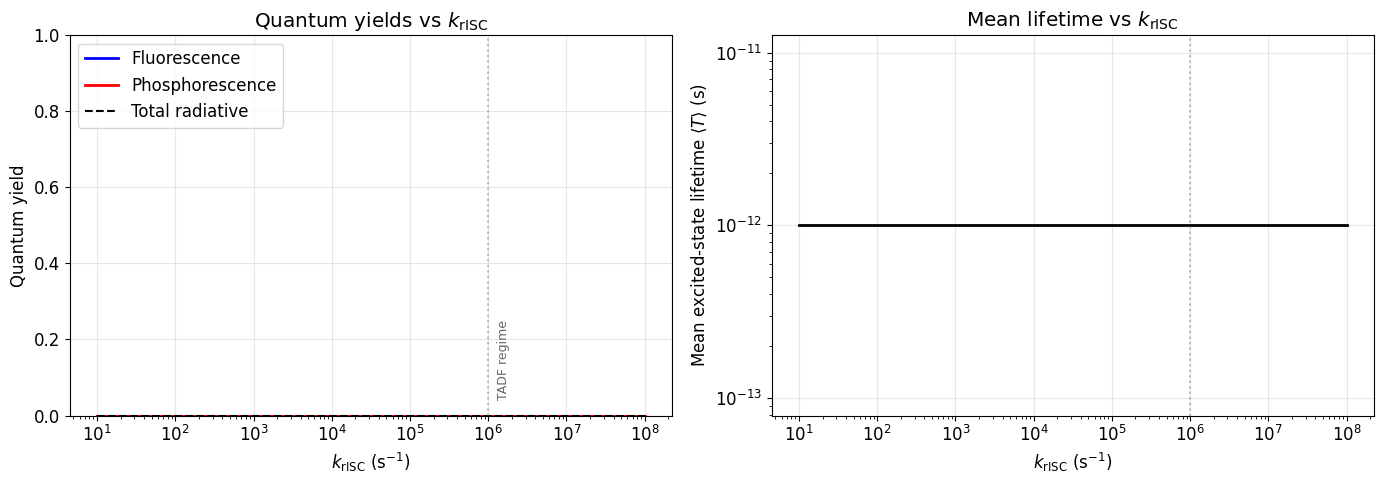

Key insight: increasing k_rISC (reducing ΔE_ST) recycles triplet
population back to S₁, boosting fluorescence yield but increasing
the mean excited-state lifetime — the TADF design tradeoff.


In [9]:
k_rISC_range = np.logspace(1, 8, 200)

phi_fluor = np.zeros_like(k_rISC_range)
phi_phos = np.zeros_like(k_rISC_range)
mean_tau = np.zeros_like(k_rISC_range)

for i, kr in enumerate(k_rISC_range):
    S_i, s_i, _ = build_system(
        k_IC=1e12, k_f=5e7, k_ISC=8e7, k_rISC=kr,
        k_p=1e4, k_TTA=1e3, k_nr=1e12
    )
    S_inv_i = np.linalg.inv(S_i)
    green_i = -pi @ S_inv_i
    phi_i = green_i * s_i
    phi_fluor[i] = phi_i[1]
    phi_phos[i] = phi_i[2]
    mean_tau[i] = -pi @ S_inv_i @ np.ones(4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogx(k_rISC_range, phi_fluor, 'b-', lw=2, label='Fluorescence')
ax1.semilogx(k_rISC_range, phi_phos, 'r-', lw=2, label='Phosphorescence')
ax1.semilogx(k_rISC_range, phi_fluor + phi_phos, 'k--', lw=1.5, label='Total radiative')
ax1.axvline(1e6, color='gray', ls=':', alpha=0.5)
ax1.text(1.3e6, 0.05, 'TADF regime', rotation=90, fontsize=9, color='0.4')
ax1.set_xlabel(r'$k_{\rm rISC}$ (s$^{-1}$)')
ax1.set_ylabel('Quantum yield')
ax1.set_title(r'Quantum yields vs $k_{\rm rISC}$')
ax1.legend()
ax1.set_ylim(0, 1)

ax2.loglog(k_rISC_range, mean_tau, 'k-', lw=2)
ax2.axvline(1e6, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel(r'$k_{\rm rISC}$ (s$^{-1}$)')
ax2.set_ylabel(r'Mean excited-state lifetime $\langle T \rangle$ (s)')
ax2.set_title(r'Mean lifetime vs $k_{\rm rISC}$')

plt.tight_layout()
plt.show()

print("Key insight: increasing k_rISC (reducing ΔE_ST) recycles triplet")
print("population back to S₁, boosting fluorescence yield but increasing")
print("the mean excited-state lifetime — the TADF design tradeoff.")

### Comparison with the decay chain

| Property | Decay chain | Jablonski diagram |
|----------|-------------|-------------------|
| Matrix structure | Lower bidiagonal | Non-triangular (rISC) |
| Reversibility | None | S₁ ⇌ T₁ |
| Branching | None (serial) | Multiple exit channels |
| Exit channels | 1 (last isotope) | 3 (fluorescence, phosphorescence, NR) |
| Timescale range | ~10²³ | ~10⁹ |
| Phase-type class | Coxian | General |

The non-triangular structure means the eigenvalues of $\mathbf{S}$ don't sit directly on the diagonal — they're mixed by the S₁ ⇌ T₁ coupling. This is what creates the biexponential (prompt + delayed) emission signature that is the hallmark of TADF.